In [1]:
import sys
if '../' not in sys.path:
    sys.path.append('../')

In [2]:
import torch
from torch import nn
from gromo.utils.utils import global_device
from gromo.containers.growing_dag import GrowingDAG
from gromo.containers.growing_container import GrowingContainer
from gromo.containers.growing_graph_network import GrowingGraphNetwork
from gromo.modules.growing_module import MergeGrowingModule, GrowingModule
from gromo.modules.conv2d_growing_module import Conv2dMergeGrowingModule, FullConv2dGrowingModule
from gromo.modules.linear_growing_module import LinearMergeGrowingModule, LinearGrowingModule
from wrappers.exp_graph_growing_net import ExpGrowingGraphNetwork
from tools.utils import evaluate_dataset, evaluate, mini_batch_gradient_descent, line_search
from tools.datasets import get_dataset
# from auxilliary_functions import line_search

device = global_device()
device

device(type='cuda')

In [3]:
import operator
from tqdm import tqdm
import matplotlib.pyplot as plt
import gc
import numpy as np

In [4]:
batch_size = 8
width = 28
img_features = width * width

In [5]:
in_channels = 3
kernel_size = (5,5)
hidden_channels = 5
out_channels = 5
padding = 0
stride = 1
hidden_width = int((width - kernel_size[0] + 2*padding) / stride) + 1  # 24
hidden_features = int((hidden_width - kernel_size[0] + 2*padding) / stride) + 1  # 20
out_features = 2
print(f"{hidden_width=}, {hidden_features=}")

hidden_width=24, hidden_features=20


In [6]:
x = torch.rand(batch_size, in_channels, width, width).to(device)
y = torch.rand(batch_size, out_features).argmax(dim=1).to(device)
print(x.shape)
print(y.shape)

torch.Size([8, 3, 28, 28])
torch.Size([8])


In [7]:
dataset = torch.utils.data.TensorDataset(x, y)
dataloader = torch.utils.data.DataLoader(dataset)
dataloader

In [8]:
val_dataset = torch.utils.data.TensorDataset(torch.rand(batch_size, in_channels, width, width, requires_grad=True), torch.rand(batch_size, out_features))
val_dataloader = torch.utils.data.DataLoader(val_dataset)
val_dataloader

# Sequential Case

In [9]:
net = nn.Sequential(
    Conv2dMergeGrowingModule(in_channels=in_channels, input_size=width, input_volume=in_channels*img_features+1, next_kernel_size=kernel_size),
    FullConv2dGrowingModule(in_channels=in_channels, out_channels=hidden_channels, kernel_size=kernel_size, input_size=(width, width)),
    Conv2dMergeGrowingModule(in_channels=hidden_channels, input_size=hidden_width, next_kernel_size=kernel_size), #input_volume=hidden_channels*hidden_width*hidden_width),
    FullConv2dGrowingModule(in_channels=hidden_channels, out_channels=out_channels, kernel_size=kernel_size, input_size=(hidden_width, hidden_width)),
    Conv2dMergeGrowingModule(in_channels=out_channels, input_size=hidden_features, post_merge_function=nn.Flatten(), next_kernel_size=hidden_features), #input_volume=out_channels*hidden_features*hidden_features),
    nn.Flatten(),
    LinearGrowingModule(in_features=out_channels * hidden_features * hidden_features, out_features=out_features),
    LinearMergeGrowingModule(in_features=out_features)
).to(device)

In [10]:
net

Sequential(
  (0): Conv2dMergeGrowingModule module with no previous modules and no next modules.
  (1): Conv2dGrowingModule(FullConv2dGrowingModule)(in_channels=3, out_channels=5, use_bias=True)
  (2): Conv2dMergeGrowingModule module with no previous modules and no next modules.
  (3): Conv2dGrowingModule(FullConv2dGrowingModule)(in_channels=5, out_channels=5, use_bias=True)
  (4): Conv2dMergeGrowingModule module with no previous modules and no next modules.
  (5): Flatten(start_dim=1, end_dim=-1)
  (6): LinearGrowingModule(LinearGrowingModule)(in_features=2000, out_features=2, use_bias=True)
  (7): LinearMergeGrowingModule module with no previous modules and no next modules.
)

In [11]:
net[1].tensor_s._update_function

<bound method Conv2dGrowingModule.compute_s_update of Conv2dGrowingModule(FullConv2dGrowingModule)(in_channels=3, out_channels=5, use_bias=True)>

In [12]:
FullConv2dGrowingModule(in_channels=in_channels, out_channels=hidden_channels, kernel_size=kernel_size, input_size=(width, width)).tensor_s._update_function

<bound method Conv2dGrowingModule.compute_s_update of Conv2dGrowingModule(FullConv2dGrowingModule)(in_channels=3, out_channels=5, use_bias=True)>

In [13]:
net[0].out_features

2353

In [14]:
net[1].input_volume

2352

In [15]:
net[0].set_next_modules([net[1]])
net[1].previous_module = net[0]
net[1].next_module = net[2]
net[2].set_previous_modules([net[1]])
net[2].set_next_modules([net[3]])
net[3].previous_module = net[2]
net[3].next_module = net[4]
net[4].set_previous_modules([net[3]])
net[4].set_next_modules([net[6]])
net[6].previous_module = net[4]
net[6].next_module = net[7]
net[7].set_previous_modules([net[6]])

for i, module in enumerate(net):
    print(i, module)
    if isinstance(module, torch.nn.Flatten): continue
    try:
        # print(f"\t{module.in_channels=}")
        # print(f"\t{module.out_channels=}")
        # print(f"\t{module.input_size=}")
        print(f"\t{module.in_features=}")
        print(f"\t{module.out_features=}")
        print(f"\t{module.previous_modules=}")
        print(f"\t{module.next_modules=}")
    except:
        print(f"\t{module.previous_module=}")
        print(f"\t{module.next_module=}")
    try:
        print(f"\t{module.input_volume=}")
    except:
        pass


0 Conv2dMergeGrowingModule module with no previous modules and 1 next modules.
	module.in_features=3
	module.out_features=2353
	module.previous_modules=[]
	module.next_modules=[Conv2dGrowingModule(FullConv2dGrowingModule)(in_channels=3, out_channels=5, use_bias=True)]
	module.input_volume=2353
1 Conv2dGrowingModule(FullConv2dGrowingModule)(in_channels=3, out_channels=5, use_bias=True)
	module.in_features=75
	module.out_features=2880
	module.previous_module=Conv2dMergeGrowingModule module with no previous modules and 1 next modules.
	module.next_module=Conv2dMergeGrowingModule module with 1 previous modules and 1 next modules.
	module.input_volume=2352
2 Conv2dMergeGrowingModule module with 1 previous modules and 1 next modules.
	module.in_features=5
	module.out_features=2880
	module.previous_modules=[Conv2dGrowingModule(FullConv2dGrowingModule)(in_channels=3, out_channels=5, use_bias=True)]
	module.next_modules=[Conv2dGrowingModule(FullConv2dGrowingModule)(in_channels=5, out_channels=5

/home/sdouka/Documents/Projects/Github/gromo/src/gromo/modules/conv2d_growing_module.py:73: UserWarning: Using property in_features in Conv2dMergeGrowingModule module with no previous modules and 1 next modules.
  warn(f"Using property in_features in {self}")
/home/sdouka/Documents/Projects/Github/gromo/src/gromo/modules/conv2d_growing_module.py:73: UserWarning: Using property in_features in Conv2dMergeGrowingModule module with 1 previous modules and 1 next modules.
  warn(f"Using property in_features in {self}")


In [16]:
print(net[2].previous_tensor_s._shape)
print(net[2].previous_tensor_m._shape)
print(net[2].tensor_s._shape)
print(net[3].tensor_s._shape)
print(net[3].tensor_m._shape)
print()
print(net[4].previous_tensor_s._shape)
print(net[4].tensor_s._shape)
print(net[6].tensor_s._shape)
print(net[6].tensor_m._shape)

(76, 76)
(76, 5)
(126, 126)
(126, 126)
(126, 5)

(126, 126)
(2001, 2001)
(2001, 2001)
(2001, 2)


In [17]:
print(net[1].in_features)
print(net[1].out_features)
print(net[2].input_volume)
print(net[2].out_features)
print(net[3].input_volume)

75
2880
2880
2880
2880


In [18]:
print(net[2].input_volume)
print(net[2].previous_modules[0].out_features)
net[2].total_out_features

2880
2880


2000

In [19]:
print(net[1].out_features)
print(net[2].out_features)
print(net[1].out_width)
print(net[1].out_height)

2880
2880
24
24


In [20]:
net(x).shape

torch.Size([8, 2])

Increase input channels of net[3]

In [21]:
net

Sequential(
  (0): Conv2dMergeGrowingModule module with no previous modules and 1 next modules.
  (1): Conv2dGrowingModule(FullConv2dGrowingModule)(in_channels=3, out_channels=5, use_bias=True)
  (2): Conv2dMergeGrowingModule module with 1 previous modules and 1 next modules.
  (3): Conv2dGrowingModule(FullConv2dGrowingModule)(in_channels=5, out_channels=5, use_bias=True)
  (4): Conv2dMergeGrowingModule module with 1 previous modules and 1 next modules.
  (5): Flatten(start_dim=1, end_dim=-1)
  (6): LinearGrowingModule(LinearGrowingModule)(in_features=2000, out_features=2, use_bias=True)
  (7): LinearMergeGrowingModule module with 1 previous modules and no next modules.
)

In [22]:
class Net(GrowingContainer):
    def __init__(self) -> None:
        super().__init__(in_features=net[0].input_volume, out_features=net[-1].out_features, device=device)
        self.net = net
    
    def set_growing_layers(self):
        # for layer in self.net:
        #     if isinstance(layer, torch.nn.Flatten): continue
        #     if isinstance(layer, Conv2dMergeGrowingModule) and len(layer.previous_modules) < 1: continue
        #     if isinstance(layer, MergeGrowingModule): continue
        #     self._growing_layers.append(layer)
        self._growing_layers.append(net[3])
        self._growing_layers.append(net[6])
    
    def forward(self, x):
        return self.net(x)
    
    def extended_forward(self, x):
        x_ext = None
        for layer in self.net:
            if isinstance(layer, GrowingModule):
                x, x_ext = layer.extended_forward(x, x_ext)
            else:
                x = layer(x)
                if x_ext is not None: 
                    x_ext = layer(x_ext)
        return x
    
    @property
    def layers(self):
        return self._growing_layers

In [23]:
model = Net()
model.set_growing_layers()
model.layers

[Conv2dGrowingModule(FullConv2dGrowingModule)(in_channels=5, out_channels=5, use_bias=True),
 LinearGrowingModule(LinearGrowingModule)(in_features=2000, out_features=2, use_bias=True)]

In [24]:
loss_fn = torch.nn.CrossEntropyLoss(reduction="sum")

In [25]:
net[3].tensor_s._shape

(126, 126)

In [28]:
net[-1].tensor_s._shape

(3, 3)

In [31]:
model.init_computation()
# net[3].init_computation()
# demo_couple[1].tensor_s_growth.init()

y_pred = model(x)
print(y_pred)
print(y)
loss = loss_fn(y_pred, y)
loss.backward()

model.update_computation()
# net[3].update_computation()

tensor([[ 0.1267,  0.3020],
        [-0.0518,  0.1729],
        [ 0.0587,  0.2129],
        [ 0.0497,  0.1935],
        [ 0.0188,  0.1361],
        [ 0.0628,  0.2385],
        [ 0.0379,  0.1973],
        [ 0.0005,  0.2492]], device='cuda:0', grad_fn=<AddmmBackward0>)
tensor([0, 0, 1, 0, 1, 0, 1, 0], device='cuda:0')


IndexError: Dimension out of range (expected to be in range of [-2, 1], but got 2)

In [27]:
net

Sequential(
  (0): Conv2dMergeGrowingModule module with no previous modules and 1 next modules.
  (1): Conv2dGrowingModule(FullConv2dGrowingModule)(in_channels=3, out_channels=5, use_bias=True)
  (2): Conv2dMergeGrowingModule module with 1 previous modules and 1 next modules.
  (3): Conv2dGrowingModule(FullConv2dGrowingModule)(in_channels=5, out_channels=5, use_bias=True)
  (4): Conv2dMergeGrowingModule module with 1 previous modules and 1 next modules.
  (5): Flatten(start_dim=1, end_dim=-1)
  (6): LinearGrowingModule(LinearGrowingModule)(in_features=2000, out_features=2, use_bias=True)
  (7): LinearMergeGrowingModule module with 1 previous modules and no next modules.
)

In [28]:
new_channels = 10

print(model.layers[0])
omega_weight = torch.rand(model.layers[0].out_channels, new_channels, model.layers[0].kernel_size[0], model.layers[0].kernel_size[1], device=global_device())
omega_bias = torch.rand(model.layers[0].out_channels, device=global_device())
print("omega", omega_weight.shape, omega_bias.shape)
model.layers[0].extended_input_layer = model.layers[0].layer_of_tensor(omega_weight, omega_bias)
model.layers[0].scaling_factor = 1
print(f"{model.layers[0].extended_input_layer=}")

print()
print(net[1])
alpha_weight = torch.rand(new_channels, net[1].in_channels, net[1].kernel_size[0], net[1].kernel_size[1], device=global_device())
alpha_bias = torch.rand(new_channels, device=global_device())
print("alpha", alpha_weight.shape, alpha_bias.shape)
net[1].extended_output_layer = net[1].layer_of_tensor(alpha_weight, alpha_bias)
net[1].scaling_factor = 1
print(f"{net[1].extended_output_layer=}")

Conv2dGrowingModule(FullConv2dGrowingModule)(in_channels=5, out_channels=5, use_bias=True)
omega torch.Size([5, 10, 5, 5]) torch.Size([5])
model.layers[0].extended_input_layer=Conv2d(10, 5, kernel_size=(5, 5), stride=(1, 1))

Conv2dGrowingModule(FullConv2dGrowingModule)(in_channels=3, out_channels=5, use_bias=True)
alpha torch.Size([10, 3, 5, 5]) torch.Size([10])
net[1].extended_output_layer=Conv2d(3, 10, kernel_size=(5, 5), stride=(1, 1))


In [29]:
# print(model(x))
# print(model.extended_forward(x))
model(x) == model.extended_forward(x)

tensor([[False, False],
        [False, False],
        [False, False],
        [False, False],
        [False, False],
        [False, False],
        [False, False],
        [False, False]], device='cuda:0')

In [30]:
from experiments.auxilliary_functions import compute_statistics, line_search

In [31]:
def step(show=True, selected_layer=None, gamma_sample: int = 100):

    initial_loss, _ = compute_statistics(
        growing_model=model, loss_function=loss_fn, dataloader=dataloader
    )
    print(f"Initial loss: {initial_loss:.3e}")

    model.compute_optimal_updates(zero_delta=False, dtype=torch.float64)
    model.reset_computation()
    if selected_layer is None:
        model.select_best_update()
    else:
        model.select_update(selected_layer)

    selected_gamma, estimated_loss, x_sup, y_sup = line_search(
        model=model,
        loss_function=loss_fn,
        dataloader=val_dataloader,
        initial_loss=initial_loss,
        first_order_improvement=model.currently_updated_layer.first_order_improvement,
        verbose=show,
    )
    x_sup = np.array(x_sup)
    y_sup = np.array(y_sup)
    print(f"Selected gamma: {selected_gamma:.3e}, new loss: {estimated_loss:.3e}")
    print(
        f"Improvement: {initial_loss - estimated_loss:.3e}, fo improvement: {selected_gamma * model.currently_updated_layer.first_order_improvement.item():.3e}"
    )

    if show:
        window = min(5 * selected_gamma, 2 * max(x_sup))
        x, y = full_search(
            model=model,
            loss=loss_func_sum,
            dataloader=val_dataloader,
            initial_loss=None,
            first_order_improvement=model.currently_updated_layer.first_order_improvement,
            min_value=-window,
            max_value=window,
            nb_points=gamma_sample,
        )

    model.amplitude_factor = np.sqrt(selected_gamma)

    if show:
        x_min = x[np.argmin(y)]
        plt.axvline(x_min, color="red", label=f"Minimum {x_min:.3e}")
        plt.plot(x, y)
        plt.plot(
            x,
            -x * model.currently_updated_layer.first_order_improvement.item()
            + initial_loss,
            label=f"First order improvement {model.currently_updated_layer.first_order_improvement.item():.3e}",
        )
        selected_sup = x_sup < window
        plt.scatter(0, initial_loss, color="blue", label="Initial loss")
        plt.scatter(
            x_sup[selected_sup],
            y_sup[selected_sup],
            color="green",
            label="Line search",
            marker="x",
        )
        plt.scatter(selected_gamma, estimated_loss, color="red", label="Selected gamma")
        plt.ylim(0, 1.1 * max(y))
        plt.legend()

    model.apply_change()

In [32]:
# step()

# Parallel Case

In [33]:
class Net(GrowingContainer):
    def __init__(self) -> None:
        input_volume=in_channels*img_features+1
        super().__init__(in_features=input_volume, out_features=out_features, device=device)
        self.start = Conv2dMergeGrowingModule(in_channels=in_channels, input_size=width, input_volume=input_volume, next_kernel_size=kernel_size).to(device)
        self.conv1a = FullConv2dGrowingModule(use_bias = False, in_channels=in_channels, out_channels=hidden_channels, kernel_size=kernel_size, input_size=(width, width)).to(device)
        self.conv1b = FullConv2dGrowingModule(in_channels=in_channels, out_channels=hidden_channels, kernel_size=kernel_size, input_size=(width, width)).to(device)
        self.hidden = Conv2dMergeGrowingModule(in_channels=hidden_channels, input_size=hidden_width, next_kernel_size=kernel_size).to(device) #input_volume=hidden_channels*hidden_width*hidden_width),
        self.conv2a = FullConv2dGrowingModule(in_channels=hidden_channels, out_channels=out_channels, kernel_size=kernel_size, input_size=(hidden_width, hidden_width)).to(device)
        self.conv2b = FullConv2dGrowingModule(in_channels=hidden_channels, out_channels=out_channels, kernel_size=5, input_size=(hidden_width, hidden_width)).to(device)
        self.end = Conv2dMergeGrowingModule(in_channels=out_channels, input_size=hidden_features, post_merge_function=nn.Flatten(), next_kernel_size=hidden_features).to(device) #input_volume=out_channels*hidden_features*hidden_features),
        self.mlp = LinearGrowingModule(in_features=out_channels * hidden_features * hidden_features, out_features=out_features).to(device)
        self.out = LinearMergeGrowingModule(in_features=out_features).to(device)

        self.start.set_next_modules([self.conv1a, self.conv1b])
        self.conv1a.previous_module = self.start
        self.conv1b.previous_module = self.start
        self.conv1a.next_module = self.hidden
        self.conv1b.next_module = self.hidden
        self.hidden.set_previous_modules([self.conv1a, self.conv1b])
        self.hidden.set_next_modules([self.conv2a, self.conv2b])
        self.conv2a.previous_module = self.hidden
        self.conv2b.previous_module = self.hidden
        self.conv2a.next_module = self.end
        self.conv2b.next_module = self.end
        self.end.set_previous_modules([self.conv2a, self.conv2b])
        self.end.set_next_modules([self.mlp])
        self.mlp.previous_module = self.end
        self.mlp.next_module = self.out
        self.out.set_previous_modules([self.mlp])
    
    def set_growing_layers(self):
        # self._growing_layers.append(self.start)
        # self._growing_layers.append(self.conv1a)
        # self._growing_layers.append(self.conv1b)
        self._growing_layers.append(self.hidden)
        self._growing_layers.append(self.conv2a)
        self._growing_layers.append(self.conv2b)
        self._growing_layers.append(self.end)
        self._growing_layers.append(self.mlp)
        self._growing_layers.append(self.out)
    
    def forward(self, x):
        x = self.start(x)
        x_a = self.conv1a(x)
        x_b = self.conv1b(x)
        x = x_a.add(x_b)
        x = self.hidden(x)
        x_a = self.conv2a(x)
        x_b = self.conv2b(x)
        x = x_a.add(x_b)
        x = self.end(x)
        x = self.mlp(x)
        x = self.out(x)
        return x
    
    def extended_forward(self, x):
        x = self.start(x)
        x_ext = None
        x_a, x_ext_a = self.conv1a.extended_forward(x, x_ext)
        x_b, x_ext_b = self.conv1b.extended_forward(x, x_ext)
        x = x_a.add(x_b)
        if x_ext_a is not None:
            x_ext = x_ext_a.add(x_ext_b)
        else:
            x_ext = x_ext_b
        x = self.hidden(x)
        if x_ext is not None: x_ext = self.hidden(x_ext)
        else: x_ext = None
        x_a, x_ext_a = self.conv2a.extended_forward(x, x_ext)
        x_b, x_ext_b = self.conv2b.extended_forward(x, x_ext)
        x = x_a.add(x_b)
        if x_ext_a is not None:
            x_ext = x_ext_a.add(x_ext_b)
        else:
            x_ext = x_ext_b
        x = self.end(x)
        if x_ext is not None: x_ext = self.end(x_ext)
        else: x_ext = None
        x, x_ext = self.mlp.extended_forward(x, x_ext)
        x = self.out(x)
        # x_ext = self.out(x_ext)
        return x
    
    @property
    def layers(self):
        return self._growing_layers

In [34]:
model = Net()
model.set_growing_layers()


In [35]:
list(model.layers)

[Conv2dMergeGrowingModule module with 2 previous modules and 2 next modules.,
 Conv2dGrowingModule(FullConv2dGrowingModule)(in_channels=5, out_channels=5, use_bias=True),
 Conv2dGrowingModule(FullConv2dGrowingModule)(in_channels=5, out_channels=5, use_bias=True),
 Conv2dMergeGrowingModule module with 2 previous modules and 1 next modules.,
 LinearGrowingModule(LinearGrowingModule)(in_features=2000, out_features=2, use_bias=True),
 LinearMergeGrowingModule module with 1 previous modules and no next modules.]

In [36]:
for i, module in enumerate(model.layers):
    print(i, module)
    try:
        # print(f"\t{module.in_channels=}")
        # print(f"\t{module.out_channels=}")
        # print(f"\t{module.input_size=}")
        print(f"\t{module.in_features=}")
        print(f"\t{module.out_features=}")
        print(f"\t{module.previous_modules=}")
        print(f"\t{module.next_modules=}")
    except:
        print(f"\t{module.previous_module=}")
        print(f"\t{module.next_module=}")
        pass
    try:
        print(f"\t{module.input_volume=}")
    except:
        pass

0 Conv2dMergeGrowingModule module with 2 previous modules and 2 next modules.
	module.in_features=5
	module.out_features=2880
	module.previous_modules=[Conv2dGrowingModule(FullConv2dGrowingModule)(in_channels=3, out_channels=5, use_bias=False), Conv2dGrowingModule(FullConv2dGrowingModule)(in_channels=3, out_channels=5, use_bias=True)]
	module.next_modules=[Conv2dGrowingModule(FullConv2dGrowingModule)(in_channels=5, out_channels=5, use_bias=True), Conv2dGrowingModule(FullConv2dGrowingModule)(in_channels=5, out_channels=5, use_bias=True)]
	module.input_volume=2880
1 Conv2dGrowingModule(FullConv2dGrowingModule)(in_channels=5, out_channels=5, use_bias=True)
	module.in_features=125
	module.out_features=2000
	module.previous_module=Conv2dMergeGrowingModule module with 2 previous modules and 2 next modules.
	module.next_module=Conv2dMergeGrowingModule module with 2 previous modules and 1 next modules.
	module.input_volume=2880
2 Conv2dGrowingModule(FullConv2dGrowingModule)(in_channels=5, out_

/home/sdouka/Documents/Projects/Github/gromo/src/gromo/modules/conv2d_growing_module.py:72: UserWarning: Using property in_features in Conv2dMergeGrowingModule module with 2 previous modules and 2 next modules.
  warn(f"Using property in_features in {self}")
/home/sdouka/Documents/Projects/Github/gromo/src/gromo/modules/conv2d_growing_module.py:72: UserWarning: Using property in_features in Conv2dMergeGrowingModule module with 2 previous modules and 1 next modules.
  warn(f"Using property in_features in {self}")


In [37]:
model(x)

tensor([[-0.6605,  0.0256],
        [-0.8476,  0.0246],
        [-0.6763, -0.0621],
        [-0.8909, -0.0645],
        [-0.7841,  0.1144],
        [-0.6882,  0.0135],
        [-0.7463, -0.0427],
        [-0.6229,  0.1436]], device='cuda:0', grad_fn=<AddmmBackward0>)

In [38]:
model.extended_forward(x)

tensor([[-0.6605,  0.0256],
        [-0.8476,  0.0246],
        [-0.6763, -0.0621],
        [-0.8909, -0.0645],
        [-0.7841,  0.1144],
        [-0.6882,  0.0135],
        [-0.7463, -0.0427],
        [-0.6229,  0.1436]], device='cuda:0', grad_fn=<AddmmBackward0>)

In [39]:
model(x) == model.extended_forward(x)

tensor([[True, True],
        [True, True],
        [True, True],
        [True, True],
        [True, True],
        [True, True],
        [True, True],
        [True, True]], device='cuda:0')

In [40]:
loss_fn = torch.nn.CrossEntropyLoss(reduction="sum")

In [41]:
model.init_computation()

y_pred = model(x)
print(y_pred)
print(y_pred.argmax(axis=1))
print(y)
loss = loss_fn(y_pred, y)
loss.backward()

model.update_computation()

tensor([[-0.6605,  0.0256],
        [-0.8476,  0.0246],
        [-0.6763, -0.0621],
        [-0.8909, -0.0645],
        [-0.7841,  0.1144],
        [-0.6882,  0.0135],
        [-0.7463, -0.0427],
        [-0.6229,  0.1436]], device='cuda:0', grad_fn=<AddmmBackward0>)
tensor([1, 1, 1, 1, 1, 1, 1, 1], device='cuda:0')
tensor([0, 0, 0, 0, 1, 1, 1, 0], device='cuda:0')


In [42]:
new_channels = 10

print(model.conv2a)
omega_weight = torch.rand(model.conv2a.out_channels, new_channels, model.conv2a.kernel_size[0], model.conv2a.kernel_size[1], device=global_device())
omega_bias = torch.rand(model.conv2a.out_channels, device=global_device())
print("omega", omega_weight.shape, omega_bias.shape)
model.conv2a.extended_input_layer = model.conv2a.layer_of_tensor(omega_weight, omega_bias)
model.conv2a.scaling_factor = 1
print(f"{model.conv2a.extended_input_layer=}")

print()
print(model.conv2b)
omega_weight = torch.rand(model.conv2b.out_channels, new_channels, model.conv2b.kernel_size[0], model.conv2b.kernel_size[1], device=global_device())
omega_bias = torch.rand(model.conv2b.out_channels, device=global_device())
print("omega", omega_weight.shape, omega_bias.shape)
model.conv2b.extended_input_layer = model.conv2b.layer_of_tensor(omega_weight, omega_bias)
model.conv2b.scaling_factor = 1
print(f"{model.conv2b.extended_input_layer=}")

print()
print(model.conv1a)
alpha_weight = torch.rand(new_channels, model.conv1a.in_channels, model.conv1a.kernel_size[0], model.conv1a.kernel_size[1], device=global_device())
alpha_bias = torch.rand(new_channels, device=global_device())
print("alpha", alpha_weight.shape, alpha_bias.shape)
if model.conv1a.use_bias:
    model.conv1a.extended_output_layer = model.conv1a.layer_of_tensor(alpha_weight, alpha_bias)
else:
    model.conv1a.extended_output_layer = model.conv1a.layer_of_tensor(alpha_weight)
model.conv1a.scaling_factor = 1
print(f"{model.conv1a.extended_output_layer=}")

print()
print(model.conv1b)
alpha_weight = torch.rand(new_channels, model.conv1b.in_channels, model.conv1b.kernel_size[0], model.conv1b.kernel_size[1], device=global_device())
alpha_bias = torch.rand(new_channels, device=global_device())
print("alpha", alpha_weight.shape, alpha_bias.shape)
if model.conv1b.use_bias:
    model.conv1b.extended_output_layer = model.conv1b.layer_of_tensor(alpha_weight, alpha_bias)
else:
    model.conv1b.extended_output_layer = model.conv1b.layer_of_tensor(alpha_weight)
model.conv1b.scaling_factor = 1
print(f"{model.conv1b.extended_output_layer=}")

Conv2dGrowingModule(FullConv2dGrowingModule)(in_channels=5, out_channels=5, use_bias=True)
omega torch.Size([5, 10, 5, 5]) torch.Size([5])
model.conv2a.extended_input_layer=Conv2d(10, 5, kernel_size=(5, 5), stride=(1, 1))

Conv2dGrowingModule(FullConv2dGrowingModule)(in_channels=5, out_channels=5, use_bias=True)
omega torch.Size([5, 10, 5, 5]) torch.Size([5])
model.conv2b.extended_input_layer=Conv2d(10, 5, kernel_size=(5, 5), stride=(1, 1))

Conv2dGrowingModule(FullConv2dGrowingModule)(in_channels=3, out_channels=5, use_bias=False)
alpha torch.Size([10, 3, 5, 5]) torch.Size([10])
model.conv1a.extended_output_layer=Conv2d(3, 10, kernel_size=(5, 5), stride=(1, 1), bias=False)

Conv2dGrowingModule(FullConv2dGrowingModule)(in_channels=3, out_channels=5, use_bias=True)
alpha torch.Size([10, 3, 5, 5]) torch.Size([10])
model.conv1b.extended_output_layer=Conv2d(3, 10, kernel_size=(5, 5), stride=(1, 1))


In [43]:
model(x) == model.extended_forward(x)

tensor([[False, False],
        [False, False],
        [False, False],
        [False, False],
        [False, False],
        [False, False],
        [False, False],
        [False, False]], device='cuda:0')

# Triangle

In [9]:
class TriangleNet(GrowingContainer):
    def __init__(self) -> None:
        input_volume=in_channels*img_features+1
        super().__init__(in_features=input_volume, out_features=out_features, device=device)
        self.start = Conv2dMergeGrowingModule(in_channels=in_channels, input_size=width, input_volume=input_volume, next_kernel_size=kernel_size).to(device)
        self.conv_skip = FullConv2dGrowingModule(in_channels=in_channels, out_channels=out_channels, kernel_size=kernel_size, input_size=(width, width)).to(device)
        self.conv_a = FullConv2dGrowingModule(in_channels=in_channels, out_channels=hidden_channels, kernel_size=kernel_size, input_size=(width, width)).to(device)
        self.hidden = Conv2dMergeGrowingModule(in_channels=hidden_channels, input_size=hidden_width, next_kernel_size=kernel_size).to(device) #input_volume=hidden_channels*hidden_width*hidden_width),
        self.conv_b = FullConv2dGrowingModule(padding=1, in_channels=hidden_channels, out_channels=out_channels, kernel_size=(3, 3), input_size=(hidden_width, hidden_width)).to(device)
        self.end = Conv2dMergeGrowingModule(in_channels=out_channels, input_size=hidden_width, post_merge_function=nn.Flatten(), next_kernel_size=kernel_size).to(device) #input_volume=out_channels*hidden_features*hidden_features),
        self.mlp = LinearGrowingModule(in_features=out_channels * hidden_width * hidden_width, out_features=out_features).to(device)
        self.out = LinearMergeGrowingModule(in_features=out_features).to(device)

        self.start.set_next_modules([self.conv_a, self.conv_skip])
        self.conv_skip.previous_module = self.start
        self.conv_skip.next_module = self.end
        self.conv_a.previous_module = self.start
        self.conv_a.next_module = self.hidden
        self.hidden.set_previous_modules([self.conv_a])
        self.hidden.set_next_modules([self.conv_b])
        self.conv_b.previous_module = self.hidden
        self.conv_b.next_module = self.end
        self.end.set_previous_modules([self.conv_skip, self.conv_b])
        self.end.set_next_modules([self.mlp])
        self.mlp.previous_module = self.end
        self.mlp.next_module = self.out
        self.out.set_previous_modules([self.mlp])
    
    def set_growing_layers(self):
        # self._growing_layers.append(self.start)
        # self._growing_layers.append(self.conv1a)
        # self._growing_layers.append(self.conv1b)
        self._growing_layers.append(self.conv_skip)
        self._growing_layers.append(self.hidden)
        self._growing_layers.append(self.conv_a)
        self._growing_layers.append(self.conv_b)
        self._growing_layers.append(self.end)
        self._growing_layers.append(self.mlp)
        self._growing_layers.append(self.out)
    
    def forward(self, x):
        x = self.start(x)
        x_skip = self.conv_skip(x)
        x = self.conv_a(x)
        x = self.hidden(x)
        x = self.conv_b(x)
        x = x.add(x_skip)
        x = self.end(x)
        x = self.mlp(x)
        x = self.out(x)
        return x
    
    def extended_forward(self, x):
        pass
        x = self.start(x)
        x_ext = None
        x_a, x_ext_a = self.conv1a.extended_forward(x, x_ext)
        x_b, x_ext_b = self.conv1b.extended_forward(x, x_ext)
        x = x_a.add(x_b)
        if x_ext_a is not None:
            x_ext = x_ext_a.add(x_ext_b)
        else:
            x_ext = x_ext_b
        x = self.hidden(x)
        if x_ext is not None: x_ext = self.hidden(x_ext)
        else: x_ext = None
        x_a, x_ext_a = self.conv2a.extended_forward(x, x_ext)
        x_b, x_ext_b = self.conv2b.extended_forward(x, x_ext)
        x = x_a.add(x_b)
        if x_ext_a is not None:
            x_ext = x_ext_a.add(x_ext_b)
        else:
            x_ext = x_ext_b
        x = self.end(x)
        if x_ext is not None: x_ext = self.end(x_ext)
        else: x_ext = None
        x, x_ext = self.mlp.extended_forward(x, x_ext)
        x = self.out(x)
        # x_ext = self.out(x_ext)
        return x
    
    @property
    def layers(self):
        return self._growing_layers

In [10]:
model = TriangleNet()
model.set_growing_layers()

In [11]:
for i, module in enumerate(model.layers):
    print(i, module)
    try:
        # print(f"\t{module.in_channels=}")
        # print(f"\t{module.out_channels=}")
        # print(f"\t{module.input_size=}")
        print(f"\t{module.in_features=}")
        print(f"\t{module.out_features=}")
        print(f"\t{module.previous_modules=}")
        print(f"\t{module.next_modules=}")
    except:
        print(f"\t{module.previous_module=}")
        print(f"\t{module.next_module=}")
        pass
    try:
        print(f"\t{module.input_volume=}")
    except:
        pass

0 Conv2dGrowingModule(FullConv2dGrowingModule)(in_channels=3, out_channels=5, use_bias=True)
	module.in_features=75
	module.out_features=2880
	module.previous_module=Conv2dMergeGrowingModule module with no previous modules and 2 next modules.
	module.next_module=Conv2dMergeGrowingModule module with 2 previous modules and 1 next modules.
	module.input_volume=2352
1 Conv2dMergeGrowingModule module with 1 previous modules and 1 next modules.
	module.in_features=5
	module.out_features=2880
	module.previous_modules=[Conv2dGrowingModule(FullConv2dGrowingModule)(in_channels=3, out_channels=5, use_bias=True)]
	module.next_modules=[Conv2dGrowingModule(FullConv2dGrowingModule)(in_channels=5, out_channels=5, use_bias=True)]
	module.input_volume=2880
2 Conv2dGrowingModule(FullConv2dGrowingModule)(in_channels=3, out_channels=5, use_bias=True)
	module.in_features=75
	module.out_features=2880
	module.previous_module=Conv2dMergeGrowingModule module with no previous modules and 2 next modules.
	module.

/home/sdouka/Documents/Projects/Github/gromo/src/gromo/modules/conv2d_growing_module.py:73: UserWarning: Using property in_features in Conv2dMergeGrowingModule module with 1 previous modules and 1 next modules.
  warn(f"Using property in_features in {self}")
/home/sdouka/Documents/Projects/Github/gromo/src/gromo/modules/conv2d_growing_module.py:73: UserWarning: Using property in_features in Conv2dMergeGrowingModule module with 2 previous modules and 1 next modules.
  warn(f"Using property in_features in {self}")


In [12]:
model

TriangleNet(
  (start): Conv2dMergeGrowingModule module with no previous modules and 2 next modules.
  (conv_skip): Conv2dGrowingModule(FullConv2dGrowingModule)(in_channels=3, out_channels=5, use_bias=True)
  (conv_a): Conv2dGrowingModule(FullConv2dGrowingModule)(in_channels=3, out_channels=5, use_bias=True)
  (hidden): Conv2dMergeGrowingModule module with 1 previous modules and 1 next modules.
  (conv_b): Conv2dGrowingModule(FullConv2dGrowingModule)(in_channels=5, out_channels=5, use_bias=True)
  (end): Conv2dMergeGrowingModule module with 2 previous modules and 1 next modules.
  (mlp): LinearGrowingModule(LinearGrowingModule)(in_features=2880, out_features=2, use_bias=True)
  (out): LinearMergeGrowingModule module with 1 previous modules and no next modules.
)

In [13]:
print(f"{model.conv_skip.out_width=}")
print(f"{model.conv_a.out_width=}")
print(f"{model.conv_b.out_width=}")

model.conv_skip.out_width=24
model.conv_a.out_width=24
model.conv_b.out_width=24


In [14]:
print(f"{model.conv_skip(x).shape=}")
print(f"{model.conv_b(model.hidden(model.conv_a(x))).shape=}")

model.conv_skip(x).shape=torch.Size([8, 5, 24, 24])
model.conv_b(model.hidden(model.conv_a(x))).shape=torch.Size([8, 5, 24, 24])


In [15]:
model(x)

tensor([[-0.1183,  0.2310],
        [-0.0995,  0.4666],
        [ 0.0089,  0.3380],
        [-0.0389,  0.2113],
        [ 0.0264,  0.4494],
        [ 0.1002,  0.4500],
        [ 0.2171,  0.3731],
        [-0.0367,  0.4010]], device='cuda:0', grad_fn=<AddmmBackward0>)

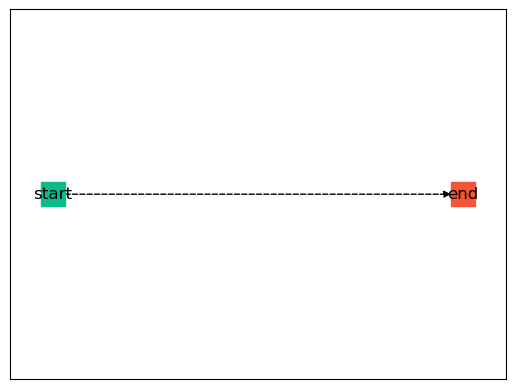

In [16]:
net = ExpGrowingGraphNetwork(
        in_features=10,
        out_features=2,
        neurons=10,
        loss_fn=torch.nn.CrossEntropyLoss(),
        layer_type="convolution",
        input_shape=28,
        with_logger=False,
)
# net.dag = dag
net.draw()

In [11]:
model = CNN(net)
model.layers

[ExpGrowingGraphNetwork(
   (loss_fn): CrossEntropyLoss()
   (dag): GrowingDAG()
 ),
 LinearMergeGrowingModule module with 1 previous modules and 1 next modules.]

In [12]:
# print(net.dag.get_node_module(net.dag.root).input_size)
# print(net.dag.get_edge_module(net.dag.root, net.dag.end).input_size)
# print(net.dag.get_node_module(net.dag.end).input_size)

In [13]:
net.dag.edges

OutEdgeView([('start', 'end')])

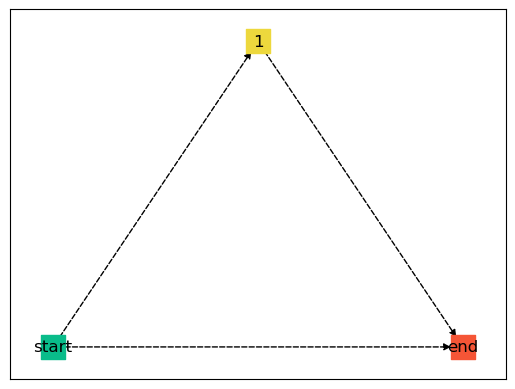

In [14]:
node = "1"
node_attributes = {
    "type": "convolution",
    "size": 5,
    "input_size": (28, 28),
    "kernel_size": (3, 3),
    "activation": "selu"
}
edge_attributes = {
    "kernel_size": (3, 3),
}
net.dag.add_node_with_two_edges(
    net.dag.root, 
    node, 
    net.dag.end, 
    node_attributes=node_attributes,
    edge_attributes=edge_attributes,
)
model.growing_dag.draw()

In [15]:
for layer in model.layers:
    if isinstance(layer, GrowingGraphNetwork):
        for sublayer in layer.dag.get_edge_modules(list(layer.dag.edges)):
            print(f"[{sublayer._name}], channels={sublayer.in_channels}, ks={sublayer.kernel_size} + {int(sublayer.use_bias)} -> {sublayer.total_in_features} features")
        for sublayer in layer.dag.get_all_node_modules():
            prevs = [prev.total_in_features for prev in sublayer.previous_modules]
            print(f"[{sublayer._name}], previous={prevs} -> {sublayer.total_in_features} features")
    else:
        print(f"[{layer.name}], features={layer.in_features} -> {layer.total_in_features} features")

[Cstart_end], channels=3, ks=(5, 5) + 1 -> 76 features
[Cstart_1], channels=3, ks=(3, 3) + 1 -> 28 features
[C1_end], channels=5, ks=(3, 3) + 1 -> 46 features
[start], previous=[] -> 0 features
[end], previous=[76, 46] -> 122 features
[1], previous=[28] -> 28 features
[LinearMergeGrowingModule], features=1568 -> 76 features


In [19]:
model.update_size()

In [22]:
for layer in model.layers:
    if isinstance(layer, GrowingGraphNetwork):
        for sublayer in layer.dag.get_edge_modules(list(layer.dag.edges)):
            print(f"[{sublayer._name}], channels={sublayer.in_channels}, ks={sublayer.kernel_size} + {int(sublayer.use_bias)} -> {sublayer.total_in_features} features")
        for sublayer in layer.dag.get_all_node_modules():
            prevs = [prev.total_in_features for prev in sublayer.previous_modules]
            print(f"[{sublayer._name}], previous={prevs} -> {sublayer.total_in_features} features")
    else:
        print(f"[{layer.name}], features={layer.in_features} -> {layer.total_in_features} features")

[Cstart_end], channels=3, ks=(5, 5) + 1 -> 76 features
[Cstart_1], channels=3, ks=(3, 3) + 1 -> 28 features
[C1_end], channels=5, ks=(3, 3) + 1 -> 46 features
[start], previous=[] -> 0 features
[end], previous=[76, 46] -> 122 features
[1], previous=[28] -> 28 features
[LinearMergeGrowingModule], features=1568 -> 122 features


In [23]:
print(net.dag.root, net.dag.get_node_module(net.dag.root).input_size)
# print(f"({net.dag.root}, {net.dag.end})", net.dag.get_edge_module(net.dag.root, net.dag.end).input_size)
print(net.dag.end, net.dag.get_node_module(net.dag.end).input_size)
print("1", net.dag.get_node_module("1").input_size)
print(f"({net.dag.root}, 1)", net.dag.get_edge_module(net.dag.root, "1").input_size)
print(f"(1, {net.dag.end})", net.dag.get_edge_module("1", net.dag.end).input_size)
print(f"output_size (1, {net.dag.end})", net.dag.get_edge_module("1", net.dag.end).out_width)

start (28, 28)
end (28, 28)
1 (28, 28)
(start, 1) (28, 28)
(1, end) (28, 28)
output_size (1, end) 28


In [24]:
print(f"activation {net.dag.end}", net.dag.get_node_module(net.dag.end).post_merge_function)
print("activation 1", net.dag.get_node_module("1").post_merge_function)

activation end Sequential(
  (0): Identity()
  (1): Identity()
)
activation 1 Sequential(
  (0): Identity()
  (1): SELU()
)


In [25]:
net.dag.nodes["start"]

{'type': 'convolution',
 'size': 3,
 'shape': 28,
 'kernel_size': (3, 3),
 'module': Conv2dMergeGrowingModule module with no previous modules and 2 next modules.}

In [26]:
net.dag.nodes["1"]

{'type': 'convolution',
 'size': 5,
 'input_size': (28, 28),
 'kernel_size': (3, 3),
 'activation': 'selu',
 'module': Conv2dMergeGrowingModule module with 1 previous modules and 1 next modules.}